<a href="https://colab.research.google.com/github/Orestis769/Data_journalism_Orestis_Savvas/blob/main/Billionaires_Homework_Orestis_Savvas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Homework Δισεκατομμυριούχοι


## 1) Διαβάστε το αρχείο `richpeople.xlsx` και προσέξτε ότι είναι ένα Excel αρχείο, οπότε πρέπει να το διαβάσουμε χρησιμοποιώντας το  `read_excel` αντί για το `read_csv`.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline

# fortwnw to excel apo to github
url = "https://raw.githubusercontent.com/datajour-gr/Data_journalism/master/week5/Homework/richpeople.xlsx"
df = pd.read_excel(url)

# deigma apo ta data
df.head()


,year,name,rank,citizenship,countrycode,networthusbillion,selfmade,typeofwealth,gender,age,...,relationshiptocompany,foundingdate,gdpcurrentus,sourceofwealth,notes,notes2,source,source_2,source_3,source_4
0,2001,A Jerrold Perenchio,151,United States,USA,3.0,self-made,executive,male,70.0,...,former chairman and CEO,1955.0,1.062180e+13,NaN,represented Marlon Brando and Elizabeth Taylor,NaN,http://en.wikipedia.org/wiki/Jerry_Perenchio,http://www.forbes.com/profile/a-jerrold-perenc...,COLUMN ONE; A Hollywood Player Who Owns the Ga...,NaN
1,2014,A. Jerrold Perenchio,663,United States,USA,2.6,self-made,executive,male,83.0,...,former chairman and CEO,1955.0,NaN,"television, Univision",represented Marlon Brando and Elizabeth Taylor,NaN,http://en.wikipedia.org/wiki/Jerry_Perenchio,http://www.forbes.com/profile/a-jerrold-perenc...,COLUMN ONE; A Hollywood Player Who Owns the Ga...,NaN
2,2001,Abdul Al Rahman Al Jeraisy,336,Saudi Arabia,SAU,1.5,self-made,founder non-finance,male,NaN,...,founder,1956.0,1.830120e+11,NaN,NaN,NaN,http://www.jeraisy.com.sa/index.php/pages/rend...,NaN,NaN,NaN
3,2001,Abdul Aziz Al Ghurair,251,United Arab Emirates,ARE,1.9,inherited,inherited,male,47.0,...,relation,1960.0,1.030000e+11,NaN,inherited from father,NaN,NaN,NaN,NaN,NaN
4,1996,Abdul Aziz Al-Sulaiman,404,Saudi Arabia,SAU,1.0,self-made,self-made finance,male,0.0,...,founder,1968.0,1.577430e+11,NaN,NaN,NaN,http://www.arabianbusiness.com/arabian-busines...,NaN,NaN,NaN


## 2) Ελέγξτε τα data

Πόσα κελιά έχει και πόσες στήλες? Τι είδος είναι τα δεδομένα?

In [2]:
# shape = grammes kai stiles
rows, cols = df.shape

print("Grammes:", rows)
print("Stiles:", cols)
print("Synolika kelia:", rows * cols)

# types gia kathe column
print("\nTypes dedomenwn:")
print(df.dtypes)

# genikes plirofories gia ta data
print("\nInfo:")
df.info()


Grammes: 2614
Stiles: 30
Synolika kelia: 78420

Types dedomenwn:
year                         int64
name                        object
rank                         int64
citizenship                 object
countrycode                 object
networthusbillion          float64
selfmade                    object
typeofwealth                object
gender                      object
age                        float64
industry                    object
IndustryAggregates          object
region                      object
north                        int64
politicalconnection        float64
founder                      int64
generationofinheritance     object
sector                      object
company                     object
companytype                 object
relationshiptocompany       object
foundingdate               float64
gdpcurrentus               float64
sourceofwealth              object
notes                       object
notes2                      object
source                   

## 3) Ποιοι είναι οι 10 πιο πλούσιοι δισεκατομμυριούχοι? Χρησιμοποιήστε το  `networthusbillion` column.

In [3]:
# sort apo ton pio plousio ston ligotero plousio
richest_10 = df.sort_values(by="networthusbillion", ascending=False).head(10)

# emfanizw mono ta xrisima columns
richest_10[["name", "networthusbillion", "citizenship", "sourceofwealth"]]


,name,networthusbillion,citizenship,sourceofwealth
284,Bill Gates,76.0,United States,Microsoft
348,Carlos Slim Helu,72.0,Mexico,telecom
124,Amancio Ortega,64.0,Spain,retail
283,Bill Gates,58.7,United States,NaN
2491,Warren Buffett,58.2,United States,Berkshire Hathaway
1377,Larry Ellison,48.0,United States,Oracle
509,David Koch,40.0,United States,diversified
381,Charles Koch,40.0,United States,diversified
2185,Sheldon Adelson,38.0,United States,casinos
429,Christy Walton,36.7,United States,Wal-Mart


## 4) Πόσοι είναι οι άνδρες και πόσες οι γυναίκες? Ποια είναι η μέση διαφορά του πλούτου τους?

> **Συμβουλή:** Το δεύτερο μισό της ερώτησης χρειάζεται `groupby`, το πρώτο όχι.

In [4]:
# metraw posa atoma exei kathe gender
gender_counts = df["gender"].value_counts()
print(gender_counts)

# mesos ploutos ana gender
mean_wealth_by_gender = df.groupby("gender")["networthusbillion"].mean()
print("\nMesos ploutos ana fylo:")
print(mean_wealth_by_gender)

# diafora mesou ploutou: male - female
difference = mean_wealth_by_gender["male"] - mean_wealth_by_gender["female"]
print("\nDiafora male - female:", difference)


gender
male              2328
female             249
married couple       3
Name: count, dtype: int64

Mesos ploutos ana fylo:
gender
female            3.819277
male              3.516881
married couple    1.300000
Name: networthusbillion, dtype: float64

Diafora male - female: -0.3023956651347657


## 5) Ποιος είναι ο φτωχότερος δισεκατομμυριούχος? Ποιοι είναι οι 10 φτωχότεροι?

In [5]:
# ftwxoteros billionaire
poorest = df.sort_values(by="networthusbillion").head(1)
print("Ftwxoteros billionaire:")
print(poorest[["name", "networthusbillion", "citizenship"]])

# 10 ftwxoteroi billionaires
poorest_10 = df.sort_values(by="networthusbillion").head(10)
print("\n10 ftwxoteroi billionaires:")
print(poorest_10[["name", "networthusbillion", "citizenship"]])


Ftwxoteros billionaire:
               name  networthusbillion     citizenship
2591  Zdenek Bakala                1.0  Czech Republic

10 ftwxoteroi billionaires:
                        name  networthusbillion     citizenship
2591           Zdenek Bakala                1.0  Czech Republic
24           Ahmed Ali Kanoo                1.0         Bahrain
4     Abdul Aziz Al-Sulaiman                1.0    Saudi Arabia
1202               John Todd                1.0     New Zealand
1204       John Van Lieshout                1.0       Australia
1793            Otani Family                1.0           Japan
81             Alexander Vik                1.0          Norway
843           Graham Kirkham                1.0  United Kingdom
2561               Yang Keng                1.0           China
387          Charles Simonyi                1.0   United States


## 6) Ποια είναι η πιο συχνή πηγή πλούτου? Είναι διαφορετική στους άνδρες και τις γυναίκες?

> **Συμβουλή:** Ξέρετε τι κάνει το `groupby` και ξέρετε πώς μετράμε πόσες φορές υπάρχει ένα value μέσα σε ένα column. Συνδυάστε τα.

In [6]:
# pio syxni pigi ploutou synolika
most_common_source = df["sourceofwealth"].value_counts().head(10)
print("Pio syxnes piges ploutou:")
print(most_common_source)

print("\nPio syxni pigi synolika:")
print(df["sourceofwealth"].value_counts().head(1))

# pio syxni pigi ploutou ana gender me groupby + value_counts
top_source_by_gender = df.groupby("gender")["sourceofwealth"].value_counts().groupby(level=0).head(1)
print("\nPio syxni pigi ana gender:")
print(top_source_by_gender)


Pio syxnes piges ploutou:
sourceofwealth
real estate        107
diversified         69
retail              63
investments         60
pharmaceuticals     42
hedge funds         34
banking             33
construction        32
media               24
consumer goods      19
Name: count, dtype: int64

Pio syxni pigi synolika:
sourceofwealth
real estate    107
Name: count, dtype: int64

Pio syxni pigi ana gender:
gender  sourceofwealth
female  diversified         9
male    real estate       100
Name: count, dtype: int64


## 7) Ποιες εταιρίες έχουν τους περισσότερους δισεκατομμυριούχους? Κάντε ένα γράφημα με τους top 5. ένα horizontal bar graph.

> **Συμβουλή:** Πρώτα απαντήστε στην ερώτηση και μετά δοκιμάστε το `.plot()` στο τέλος.
>
> **Συμβουλή:** Μπορείτε να δοκιμάσετε το `.head()` αντί για όλο το `df`
>
> **Συμβουλή:** Μπορεί να σκέφτεστε ότι πρέπει να κάνετε `groupby`, αλλά υπάρχει ποιο εύκολος τρόπος να μετρήσετε!

company
Walmart                       18
Campbell Soup                 16
Hyatt                         15
SAP AG                        12
Sid Richardson Gasoline Co    11
Name: count, dtype: int64


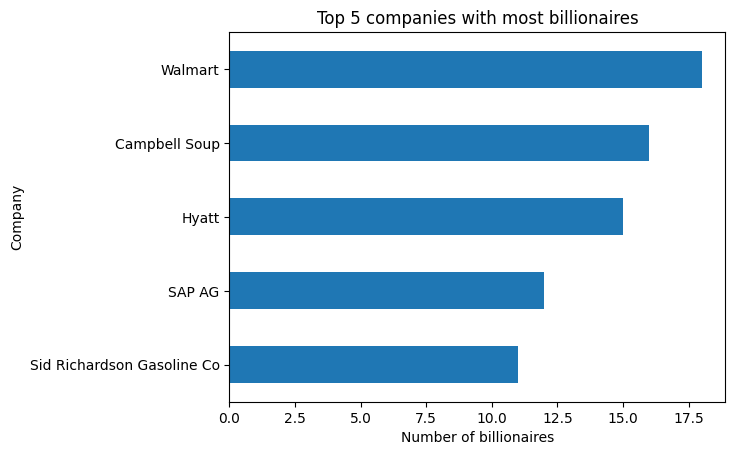

In [7]:
# metraw poses fores emfanizetai kathe company
top_companies = df["company"].value_counts().head(5)
print(top_companies)

# horizontal bar graph
top_companies.plot(kind="barh")
plt.title("Top 5 companies with most billionaires")
plt.xlabel("Number of billionaires")
plt.ylabel("Company")
plt.gca().invert_yaxis()  # megalyteri mpara panw
plt.show()


## 8) Πόσα λεφτά έχουν όλοι οι billionaires συνολικά?

In [8]:
# athroisma tou net worth olwn
total_money = df["networthusbillion"].sum()

print("Synolika lefta se billions USD:", total_money)


Synolika lefta se billions USD: 9232.5


## 9) Ποιες είναι οι top 3 χώρες στις οποίες οι billionaires έχουν τα λεφτά τους?

Δεν ρωτάω ποια χώρα έχει τους περισότερους billionaires, αλλά το συνολικό ποσό των χρημάτων ανά χώρα.

> **Συμβουλή:** Σκεφτείτε ότι πρώτα πρέπει να οργανώσετε ανά χώρα, μετά να βρείτε το net worth που έχουν και μετά όλα αυτά μαζί.

In [9]:
# omadopoiw ana xwra kai athroizw to net worth
top_3_countries_money = df.groupby("citizenship")["networthusbillion"].sum().sort_values(ascending=False).head(3)

print(top_3_countries_money)


citizenship
United States    3542.1
Germany           671.0
Russia            434.9
Name: networthusbillion, dtype: float64


## 10) Πόσο χρονών είναι ο μέσος billionaire? Πόσο χρονών είναι οι self made vs. non self made?

In [10]:
# vgazw tis lathos arnhtikes ilikies
df_age = df[df["age"] > 0]

# mesos oros ilikias
average_age = df_age["age"].mean()
print("Mesi ilikia billionaire:", round(average_age, 2))

# mesos oros ilikias ana selfmade category
age_by_selfmade = df_age.groupby("selfmade")["age"].mean()
print("\nMesi ilikia self-made vs inherited:")
print(age_by_selfmade)


Mesi ilikia billionaire: 62.58

Mesi ilikia self-made vs inherited:
selfmade
inherited    62.644068
self-made    62.522603
Name: age, dtype: float64


## 11) Ποιοι είναι οι νεότεροι billionaires? Ποιοι οι γηραιότεροι? Φτιάξτε ένα γράφημα με τη διασπορά των ηλικιών.

10 neoteroi billionaires:
                            name   age  networthusbillion    citizenship
53    Albert von Thurn und Taxis  12.0                1.5        Germany
2044                 Robert Ziff  21.0                1.0  United States
1838                 Perenna Kei  24.0                1.3      Hong Kong
475                  Daniel Ziff  24.0                1.0  United States
1352                 Kumar Birla  28.0                2.1          India
651        Emilio Azcarraga Jean  28.0                2.0         Mexico
476                  Daniel Ziff  29.0                1.2  United States
1586             Mark Zuckerberg  29.0               28.5  United States
189          Anton Kathrein, Jr.  29.0                1.4        Germany
605             Dustin Moskovitz  29.0                6.8  United States

10 giraioteroi billionaires:
                        name   age  networthusbillion    citizenship
516   David Rockefeller, Sr.  98.0                2.9  United States
127

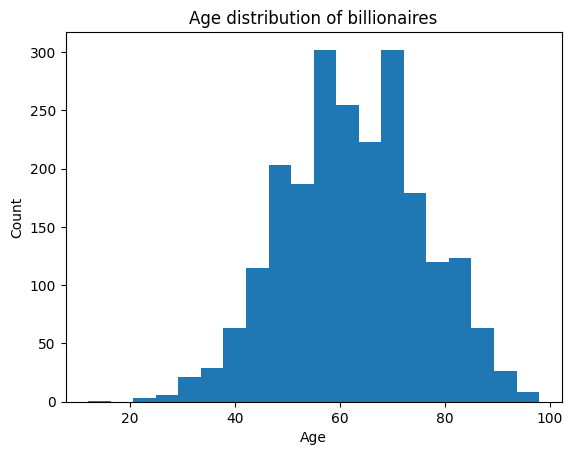

In [11]:
# kratame mono swstes ilikies panw apo 0
df_age = df[df["age"] > 0]

# 10 neoteroi
youngest_10 = df_age.sort_values(by="age").head(10)
print("10 neoteroi billionaires:")
print(youngest_10[["name", "age", "networthusbillion", "citizenship"]])

# 10 giraioteroi
oldest_10 = df_age.sort_values(by="age", ascending=False).head(10)
print("\n10 giraioteroi billionaires:")
print(oldest_10[["name", "age", "networthusbillion", "citizenship"]])

# graph gia tin katanomi/dispersia ilikiwn
df_age["age"].plot(kind="hist", bins=20)
plt.title("Age distribution of billionaires")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()


## 12) Φτιάξτε ένα scatterplot που να σχετίζει το net worth σε σχέση με την ηλικία τους.

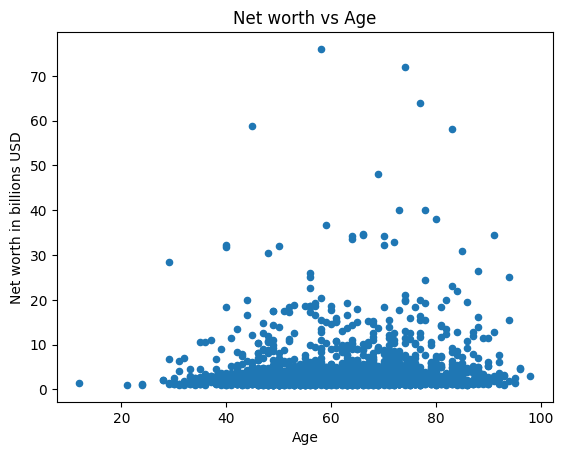

In [12]:
# scatterplot: ilikia vs ploutos
df_age = df[df["age"] > 0]

df_age.plot(kind="scatter", x="age", y="networthusbillion")
plt.title("Net worth vs Age")
plt.xlabel("Age")
plt.ylabel("Net worth in billions USD")
plt.show()


## 13) Φτιάξτε ένα γράφημα με τους top 10 πλουσιότερους billionaires

                  name  networthusbillion
284         Bill Gates               76.0
348   Carlos Slim Helu               72.0
124     Amancio Ortega               64.0
283         Bill Gates               58.7
2491    Warren Buffett               58.2
1377     Larry Ellison               48.0
509         David Koch               40.0
381       Charles Koch               40.0
2185   Sheldon Adelson               38.0
429     Christy Walton               36.7


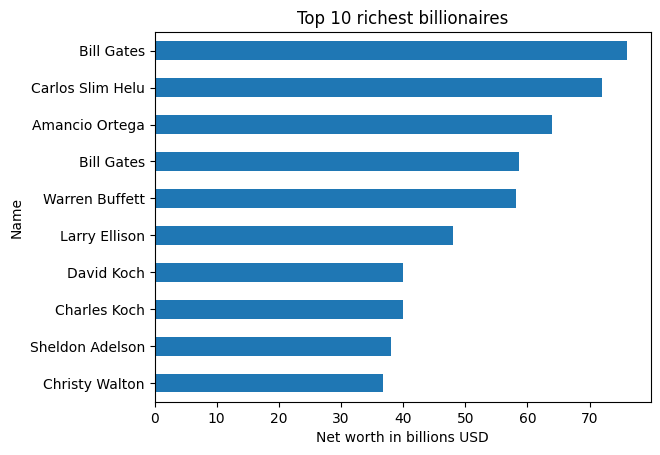

In [13]:
# top 10 plousioteroi
richest_10 = df.sort_values(by="networthusbillion", ascending=False).head(10)
print(richest_10[["name", "networthusbillion"]])

# graph me top 10 plousioterous
richest_10.plot(kind="barh", x="name", y="networthusbillion", legend=False)
plt.title("Top 10 richest billionaires")
plt.xlabel("Net worth in billions USD")
plt.ylabel("Name")
plt.gca().invert_yaxis()  # pio plousios panw
plt.show()
